# Preamble

## Imports

In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf

## Useful Functions

In [2]:
def Sigma_LBP_1(r,Mdisk,Rc) -> float:
    val = (Mdisk)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

## Simulation Parameters

In [3]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 1.0 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.32 * u.solMass #High-mass
#Mdot_0 = 5E-8 * u.solMass / u.yr  #TODO
Rc = 91.0 * u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.2 * u.solMass
Rstar = 3.0 * u.solRad
Tstar = 4395.0 * u.K
mu = 2.33

alpha_SS = 1e-3
psi = 10

# 1. Grid

In [4]:
R_in = 0.1   # AU
R_out = 400.0  # AU — must be >> Rc (91 AU) so the spreading front never reaches the boundary
Ncells = 500
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R_centers = grid.Rc  # AU

# 2. Star

In [5]:
star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

# 3. EOS

In [6]:
#eos = IrradiatedEOS(
#   star,
#    alpha_t=alpha_SS,   
#    Tc=10,                  #External/nebular temperature floor (K)
#    Tmax=1500,              #max temperature cap (K)
#    mu=mu,
#    gamma=1.0,
#    accrete=True,           #Include viscous heating from accretion
#    kappa=Zhu2012,
#    e_rad= 0.9
#)

eos = SimpleDiscEOS(star, alpha_t=1e-3)
eos.set_grid(grid)

Initial EOS solve to get zero timestep and initial LBP profile

In [7]:
#LBP profile
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])

#Set this profile as timezero
eos.update(0, Sigma_initial)

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:224: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


# 4. Disc 

In [8]:
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_initial,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

# 5. Viscous Evolution

In [9]:
visc_evol = HybridWindModel(psi_DW=psi, 
                            lambda_DW=3, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')

disc._gas = visc_evol #Attach to _gas object

# 6. Chemistry 

In [10]:
chem_model = EquilibriumCOChemOberg(fix_ratios=False, a=1e-5)

#Set solar abundances
X_solar = SimpleCOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

#Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

#Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

# 7. Fluid Drift

In [11]:
drift = SingleFluidDrift(diffusion=None, settling=True) #TODO check why diffusion=None

# 8. Driver

In [12]:
driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,  #Driver will handle updating chemistry for gas and ices
    t0=t_initial_code
)

# 9. Evolution Setup

## 9.1 runtime + output times

In [13]:
run_start_yr = t_initial_yr
run_end_yr = t_final_yr
run_duration_yr = run_end_yr - run_start_yr

output_times_yr = np.linspace(run_start_yr, run_end_yr, 10)
output_times_code = output_times_yr * yr_code

io = Event_Controller(save=output_times_code)

## 9.2 Data arrays

In [14]:
history = { 
    't_yr': [],
    'Mtot': [], 
    'Rout': [],  
    'Rc': [], 
    'Sigma_G': [], 
    'Sigma_D': [], 
    'dust_frac': [], 
    'St': [], 
    'grain_size': [], 
    'T': [], 
    'P': [], 
    'chem_ice': [], 
    'chem_gas': [], 
    'mid_gas_dens': []
}

torque_maps = {
    't_yr': [],
    'maps': []
}

#Create M-R diagram for torque maps
mass_array = np.logspace(-2,3,Ncells)                   #Mearth required by compute_torque function
radius_array = disc.R                                   #AU                               
R_grid, M_grid = np.meshgrid(radius_array, mass_array)  #2D grid from the two 1D arrays

# 10. Initial Plots

## 10.1 Plotting function

In [15]:
def plot_disc_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=alphas[i], lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(min(np.min(Sg), np.min(Sd))))), 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(d2g)))), 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=alphas[i], lw=lw)

    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 10**(np.ceil(np.log10(np.max(T)))))
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', length=2)

    plt.tight_layout()
    plt.show()


# 11. Evolution Loop

In [16]:
pbar = tqdm(total=run_duration_yr,
             unit='yr',
             desc='Evolving disc... ',
             bar_format='{desc}: {percentage:.1f}%|{bar}| {rate_fmt} [{elapsed}<{remaining}]')
last_elapsed_yr = 0.0
steps = 0
t_yr = driver.t / yr_code
last_t_yr = t_yr

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        dt = driver(ti)
        steps += 1
    
        #pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store at output times
    if io.check_event(driver.t, 'save'):
        history['t_yr'].append(driver.t / yr_code)                        #yr
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))           #Msol
        history['Rout'].append(disc.Rout())                               #AU
        history['Rc'].append(disc.RC())                                   #AU
        history['Sigma_G'].append(disc.Sigma_G.copy())                    #Total gas Sigma
        history['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy())        #Total dust Sigma, pebbles + grains
        history['dust_frac'].append(disc.dust_frac.sum(axis=0).copy())    #Total dust to gas ratio
        history['St'].append(disc.Stokes()[1].copy())                     #Pebbles not small grains
        history['grain_size'].append(disc.grain_size[1].copy())           #Pebbles not small grains
        history['T'].append(disc.T.copy())                                #Temperature
        history['P'].append(disc.P.copy())                                #Pressure
        history['chem_ice'].append(disc.chem.ice.data.copy())             
        history['chem_gas'].append(disc.chem.gas.data.copy())
        history['mid_gas_dens'].append(disc.midplane_gas_density.copy())
        io.pop_events(driver.t, 'save')

        #Torque Maps Data 
        TypeI = pf.TypeIMigration(disc)                                                     #Creates a Type I migration object from the disc object
        Torque_map = np.zeros_like(R_grid)                                                  #initialize 2D grid with all values zero 

        for i, Mp in enumerate(mass_array):
            Mp_array = np.ones_like(radius_array) * Mp                                      #Pass Mp as an array of the same shape as radius_array           
            Torque_map[i,:] = TypeI.compute_torque_not_normalized(radius_array, Mp_array)   #Compute the total torque for said mass at each R 

        torque_maps['t_yr'].append(driver.t / yr_code)
        torque_maps['maps'].append(Torque_map)

pbar.close()


print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")
print(f"Final disc outer radius: {disc.Rout():.2f} AU")

Evolving disc... : 0.0%|          | ?yr/s [00:00<?]

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/planet_formation.py:1036: RuntimeWarning: divide by zero encountered in divide
  kXi  = jp / (2*np.pi * Xi)



=== EVOLUTION COMPLETE ===
Total steps: 72249
Final time: 1.0e+06 years
Final mass: 9.902e-02 M_sun (31.4% of initial)
Final disc outer radius: 400.00 AU


# 12. Final Plots

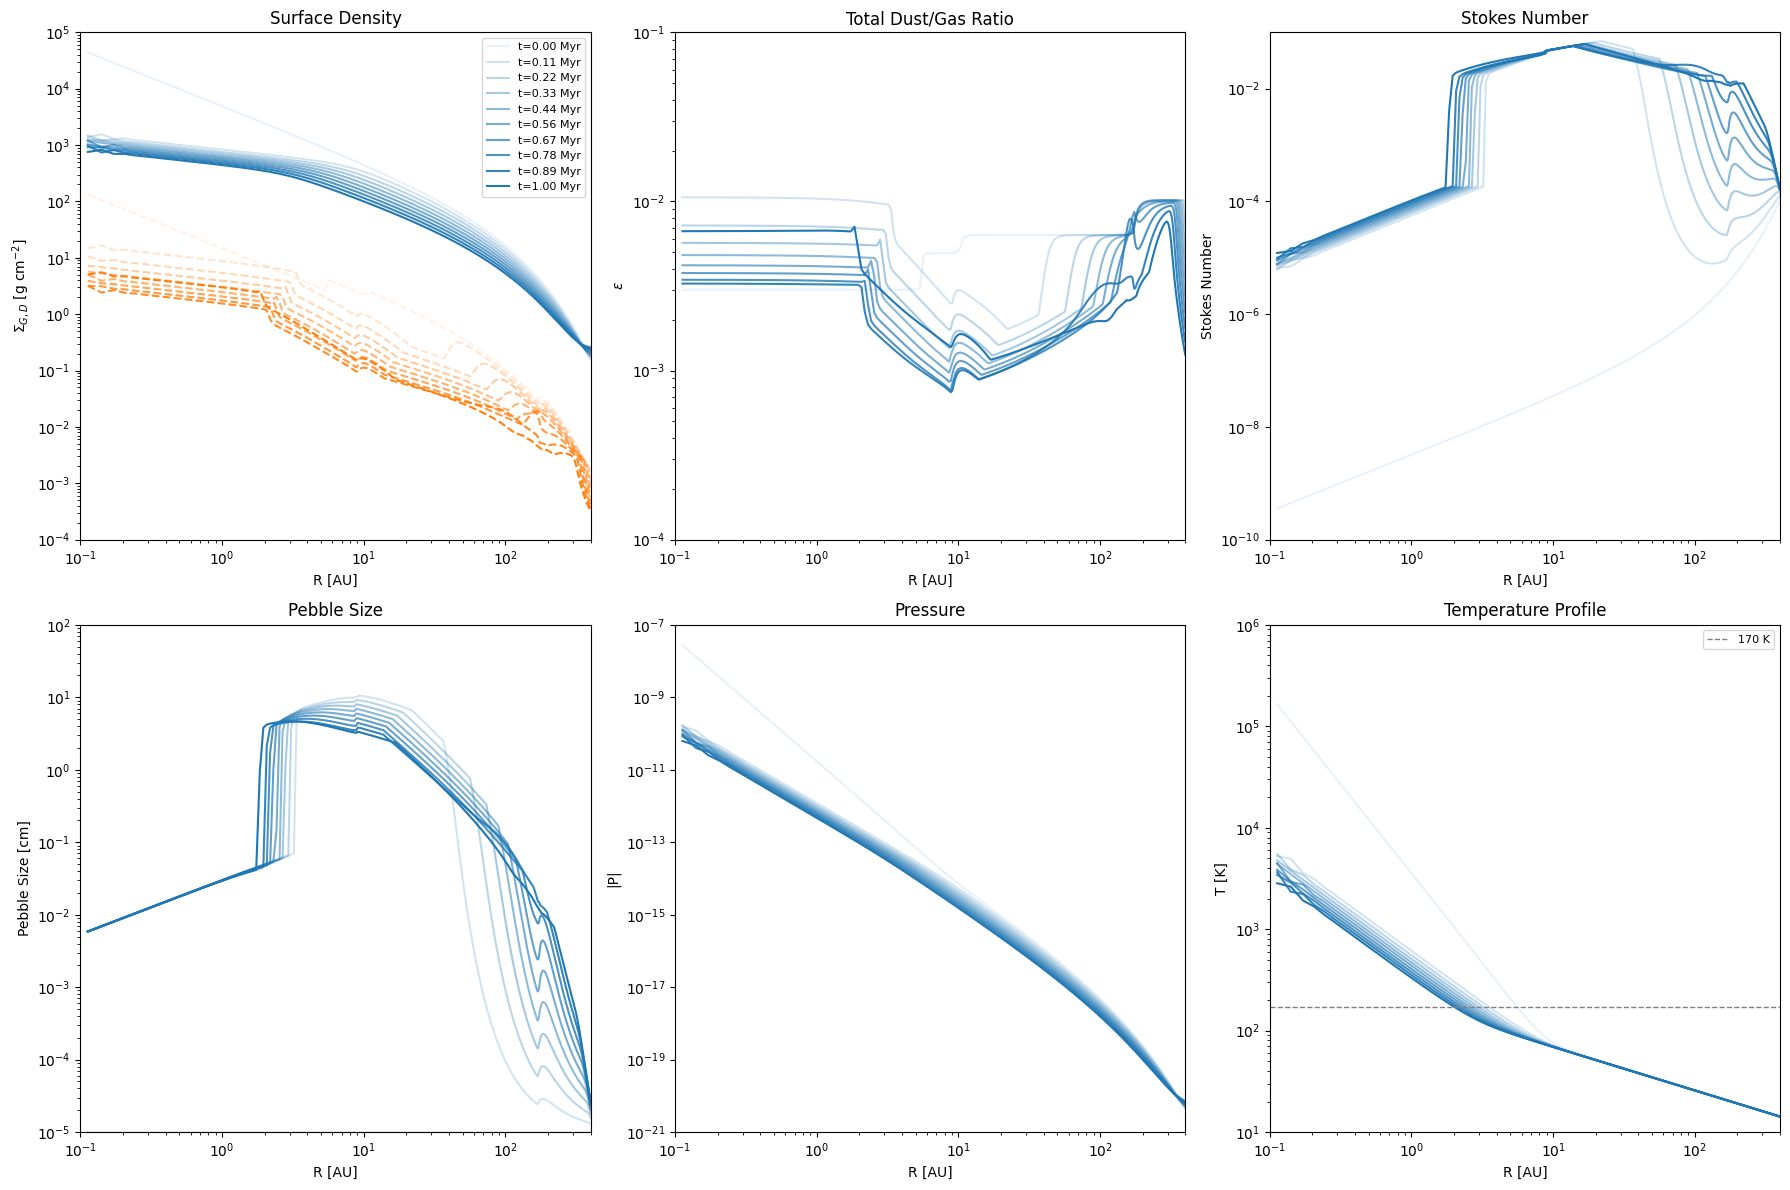

In [17]:
plot_disc_values()

# 13. Torque Maps

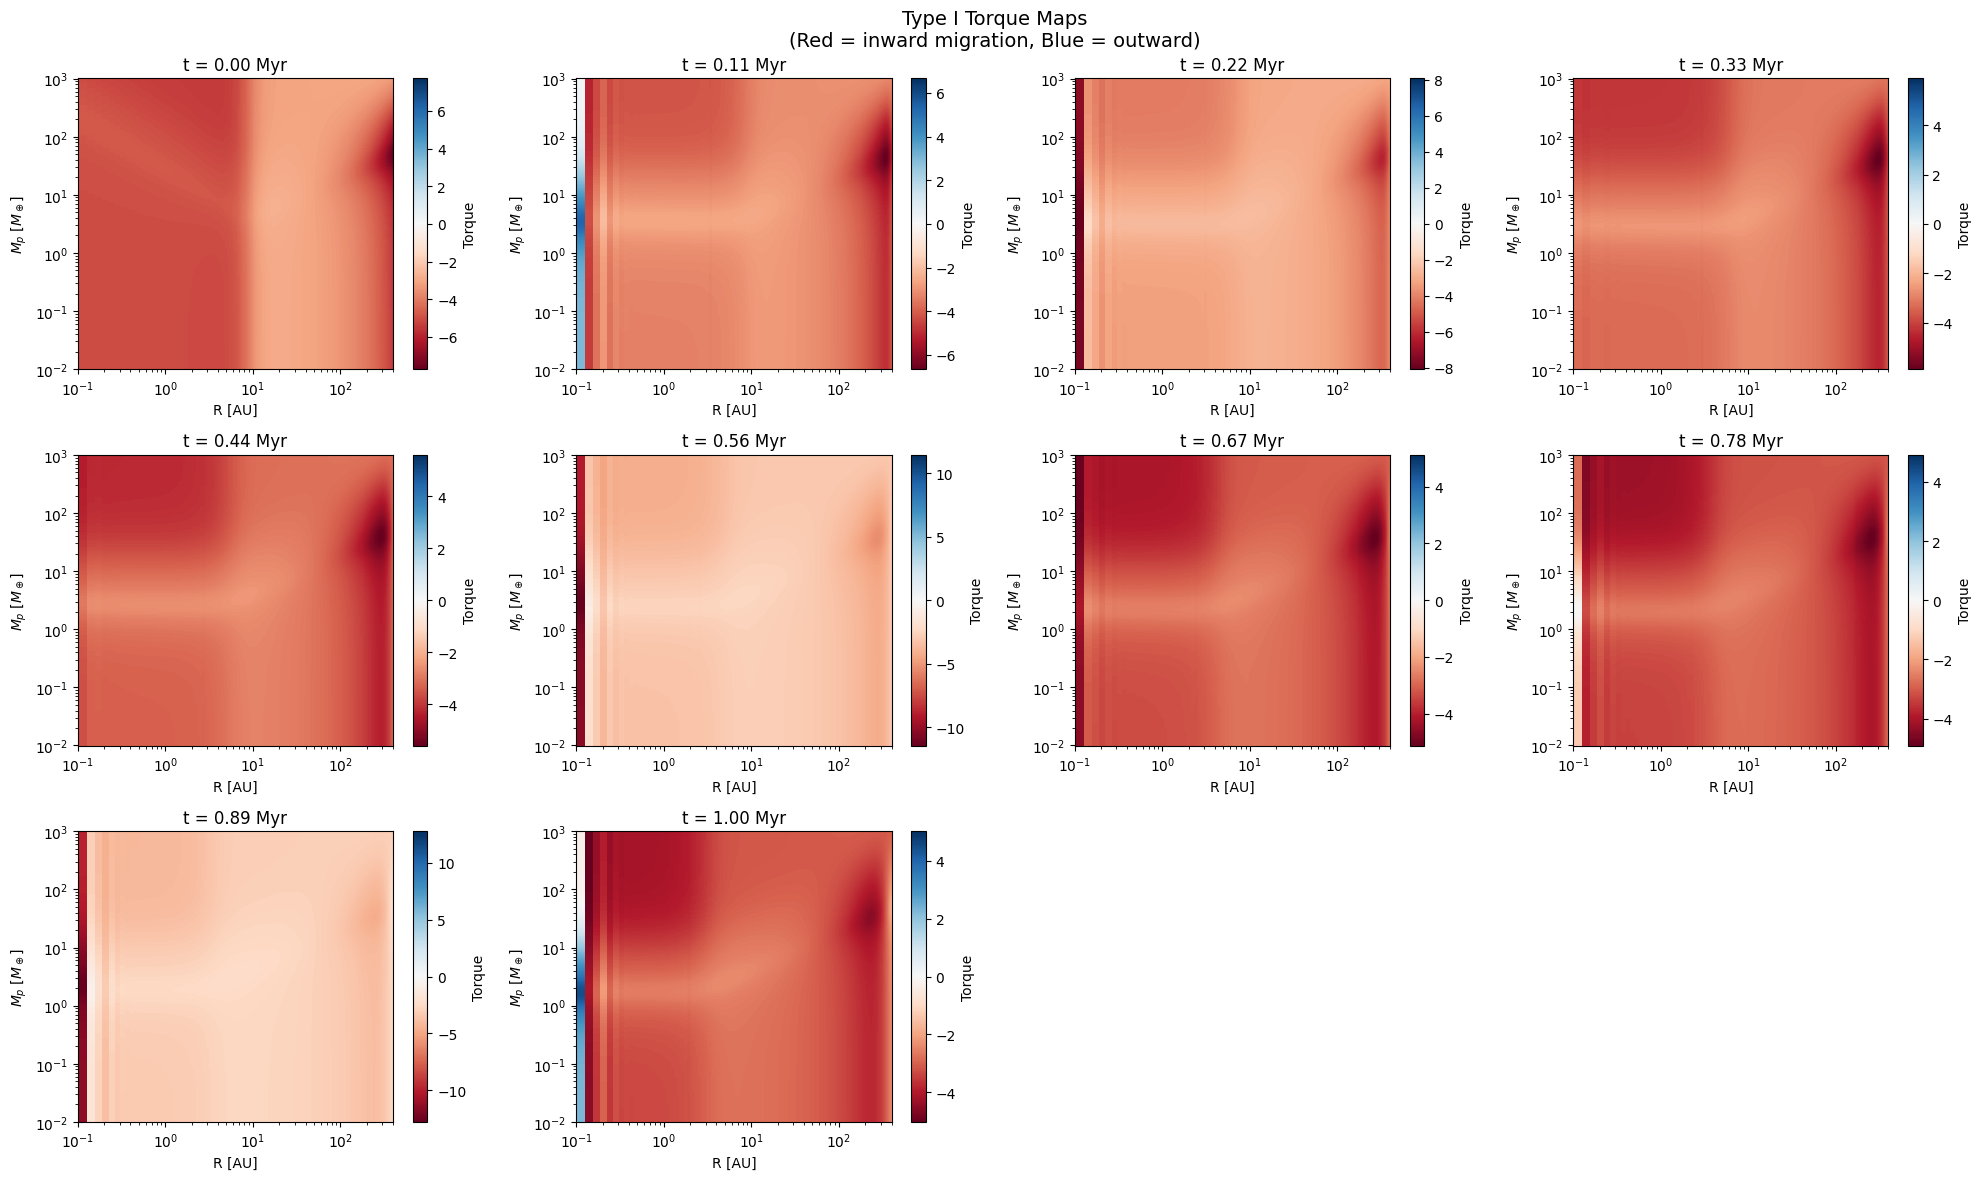

In [18]:

n_maps = len(torque_maps['maps'])
ncols = 4
nrows = int(np.ceil(n_maps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = np.atleast_2d(axes)

for idx in range(n_maps):
    ax = axes[idx // ncols, idx % ncols]
    T_map = torque_maps['maps'][idx]
    t_label = torque_maps['t_yr'][idx]

    # Symmetric colour scale around zero
    vmax = np.max(np.abs(T_map))
    vmin = -vmax

    im = ax.pcolormesh(
        radius_array, mass_array, T_map,
        cmap='RdBu',        # red = inward (negative), blue = outward (positive)
        vmin=vmin, vmax=vmax,
        shading='auto'
    )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$M_p$ [$M_\oplus$]')
    ax.set_title(f't = {t_label/1e6:.2f} Myr')
    ax.set_xlim(R_in, R_out)
    fig.colorbar(im, ax=ax, label='Torque')

# Hide unused axes
for idx in range(n_maps, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Type I Torque Maps\n(Red = inward migration, Blue = outward)', fontsize=14)
plt.tight_layout()
plt.show()
